In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sn

# Učitavanje: sep=';' jer je CSV tako spremljen
# skiprows=[1] jer drugi red (kWh, kvarh) smeta Pythonu kod računanja
df = pd.read_csv('HE Mostar 2026.csv', sep=';', skiprows=[1])

# Čišćenje imena stupaca (brišemo nevidljive razmake)
df.columns = df.columns.str.strip()

# Pretvaranje stupca 'Time' u pravi datum i sata
df['Time'] = pd.to_datetime(df['Time'], dayfirst=True)

# Prikaz da vidimo da li sve sjelo na svoje mjesto
df.head()

,Time,Generator 1 aktivno primanje,Generator 1 aktivno davanje,Generator 1 reaktivno primanje,Generator 1 reaktivno davanje,Generator 2 aktivno primanje,Generator 2 aktivno davanje,Generator 2 reaktivno primanje,Generator 2 reaktivno davanje,Generator 3 aktivno primanje,Generator 3 aktivno davanje,Generator 3 reaktivno primanje,Generator 3 reaktivno davanje
0,2025-01-01 01:00:00,0,11.781,0.0,2.508,0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2025-01-01 02:00:00,0,14.405,0.0,1.584,0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,2025-01-01 03:00:00,0,11.798,231.0,215.000,0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,2025-01-01 04:00:00,0,11.781,215.0,149.000,0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,2025-01-01 05:00:00,0,11.781,0.0,891.000,0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [2]:
# 1. Koliko imamo redova i stupaca
print(f"Dataset ima {df.shape[0]} redova i {df.shape[1]} stupaca.")

# 2. Brojanje nedostajućih vrijednosti (isnull)
print("\n--- Broj praznih polja po stupcima ---")
print(df.isnull().sum())

Dataset ima 8760 redova i 13 stupaca.

--- Broj praznih polja po stupcima ---
Time                              0
Generator 1 aktivno primanje      0
Generator 1 aktivno davanje       0
Generator 1 reaktivno primanje    0
Generator 1 reaktivno davanje     0
Generator 2 aktivno primanje      0
Generator 2 aktivno davanje       0
Generator 2 reaktivno primanje    0
Generator 2 reaktivno davanje     0
Generator 3 aktivno primanje      0
Generator 3 aktivno davanje       0
Generator 3 reaktivno primanje    0
Generator 3 reaktivno davanje     0
dtype: int64


In [3]:
# Statistički pregled svih mjerenja
print("--- STATISTIČKA ANALIZA RADA ELEKTRANE ---")
df.describe()

--- STATISTIČKA ANALIZA RADA ELEKTRANE ---


,Time,Generator 1 aktivno primanje,Generator 1 aktivno davanje,Generator 1 reaktivno primanje,Generator 1 reaktivno davanje,Generator 2 aktivno primanje,Generator 2 aktivno davanje,Generator 2 reaktivno primanje,Generator 2 reaktivno davanje,Generator 3 aktivno primanje,Generator 3 aktivno davanje,Generator 3 reaktivno primanje,Generator 3 reaktivno davanje
count,8760,8760.0,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2025-07-02 13:04:30.821918,0.0,11.751453,119.125315,115.267920,0.001941,8.467192,84.506775,69.150974,0.001941,7.872799,67.174575,67.292076
min,2025-01-01 01:00:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-04-02 07:45:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2025-07-02 13:30:00,0.0,11.303000,0.000000,1.023000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2025-10-01 19:15:00,0.0,17.820000,99.000000,66.000000,0.000000,15.692000,2.116250,1.473000,0.000000,14.673000,1.287000,1.452000
max,2026-01-01 00:00:00,0.0,957.000000,990.000000,990.000000,17.000000,974.000000,990.000000,990.000000,17.000000,974.000000,990.000000,990.000000
std,NaN,0.0,29.613392,232.663036,235.259178,0.181634,29.983874,207.808426,189.521856,0.181634,33.781541,180.860368,189.204821


In [4]:
# 1. Detaljan pregled tipova podataka (Dtype) i memorije
# Cilj je provjeriti jesu li svi generatori prepoznati kao brojevi (float64)
print("--- DETALJNI INFO O PODACIMA ---")
df.info()

# 2. Provjera postoje li identični redovi (duplikati)
# Ako ispiše False, znači da je svaki sat u godini jedinstven i podaci su uredni
print("\nPostoje li dupli redovi u podacima?")
print(df.duplicated().any())

--- DETALJNI INFO O PODACIMA ---
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Time                            8760 non-null   datetime64[us]
 1   Generator 1 aktivno primanje    8760 non-null   int64         
 2   Generator 1 aktivno davanje     8760 non-null   float64       
 3   Generator 1 reaktivno primanje  8760 non-null   float64       
 4   Generator 1 reaktivno davanje   8760 non-null   float64       
 5   Generator 2 aktivno primanje    8760 non-null   int64         
 6   Generator 2 aktivno davanje     8760 non-null   float64       
 7   Generator 2 reaktivno primanje  8760 non-null   float64       
 8   Generator 2 reaktivno davanje   8760 non-null   float64       
 9   Generator 3 aktivno primanje    8760 non-null   int64         
 10  Generator 3 aktivno davanje     8760 non-null   fl

Broj praznih polja po stupcima:
Time                              0
Generator 1 aktivno primanje      0
Generator 1 aktivno davanje       0
Generator 1 reaktivno primanje    0
Generator 1 reaktivno davanje     0
Generator 2 aktivno primanje      0
Generator 2 aktivno davanje       0
Generator 2 reaktivno primanje    0
Generator 2 reaktivno davanje     0
Generator 3 aktivno primanje      0
Generator 3 aktivno davanje       0
Generator 3 reaktivno primanje    0
Generator 3 reaktivno davanje     0
dtype: int64


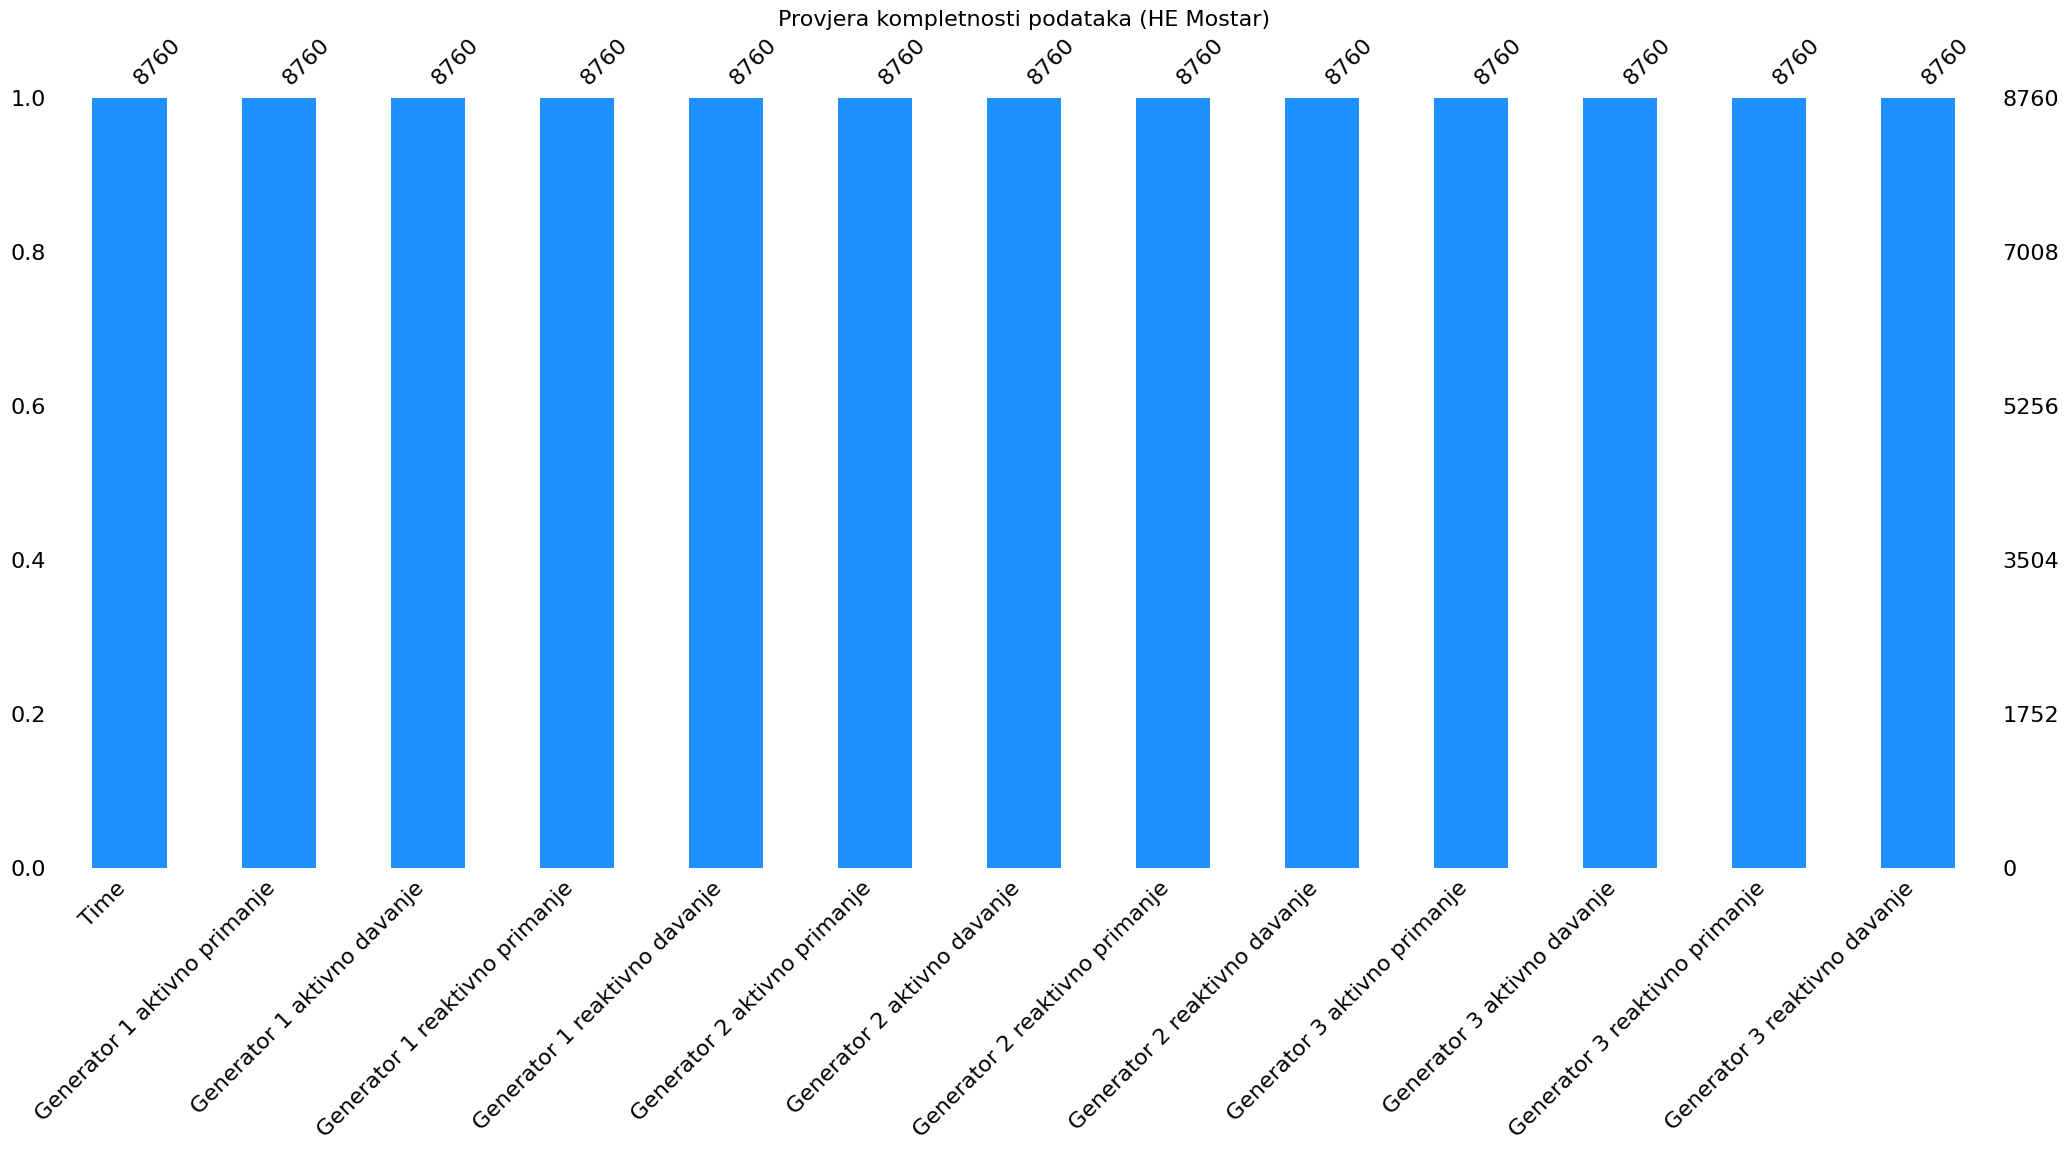

In [ ]:
# 1. Brojčani prikaz praznih polja
print("Broj praznih polja po stupcima:")
print(df.isnull().sum())

# 2. Vizualni prikaz (pomoću missingno biblioteke koju sam uvezao)
# Ovaj grafikon će pokazati pune stupce ako nema rupa
msno.bar(df, color="dodgerblue")
plt.title("Provjera kompletnosti podataka (HE Mostar)", fontsize=16)
plt.show()

In [ ]:
# 1. Određujemo koji su stupci brojevi (jer ne možemo računati prosjek za vrijeme)
numericki_stupci = df.select_dtypes(include=[np.number]).columns

# 2. Popunjavamo prazna polja (NaN) srednjom vrijednošću (mean) svakog stupca
# Napomena:Rezultat ostati isti jer nema praznih polja, 
# ali ovo je nezaobilazan korak u projektu.
df[numericki_stupci] = df[numericki_stupci].fillna(df[numericki_stupci].mean())

# 3. Provjera - potvrda da više nema niti jedne prazne ćelije
print("Nakon popunjavanja, broj praznih polja je:")
print(df.isnull().sum())

Nakon popunjavanja, broj praznih polja je:
Time                              0
Generator 1 aktivno primanje      0
Generator 1 aktivno davanje       0
Generator 1 reaktivno primanje    0
Generator 1 reaktivno davanje     0
Generator 2 aktivno primanje      0
Generator 2 aktivno davanje       0
Generator 2 reaktivno primanje    0
Generator 2 reaktivno davanje     0
Generator 3 aktivno primanje      0
Generator 3 aktivno davanje       0
Generator 3 reaktivno primanje    0
Generator 3 reaktivno davanje     0
dtype: int64


In [ ]:
# Ponovna provjera praznih ćelija
print("--- PROVJERA NAKON ČIŠĆENJA ---")
print(df.isnull().sum())

# Vizualna potvrda - ako je sve nula,dataset je spreman za analizu
if df.isnull().sum().sum() == 0:
    print("\n✅ Čestitamo! Dataset nema praznih polja i spreman je za daljnju obradu.")
else:
    print("\n⚠️ Još uvijek postoje prazna polja.")

--- PROVJERA NAKON ČIŠĆENJA ---
Time                              0
Generator 1 aktivno primanje      0
Generator 1 aktivno davanje       0
Generator 1 reaktivno primanje    0
Generator 1 reaktivno davanje     0
Generator 2 aktivno primanje      0
Generator 2 aktivno davanje       0
Generator 2 reaktivno primanje    0
Generator 2 reaktivno davanje     0
Generator 3 aktivno primanje      0
Generator 3 aktivno davanje       0
Generator 3 reaktivno primanje    0
Generator 3 reaktivno davanje     0
dtype: int64

✅ Čestitamo! Dataset nema praznih polja i spreman je za daljnju obradu.


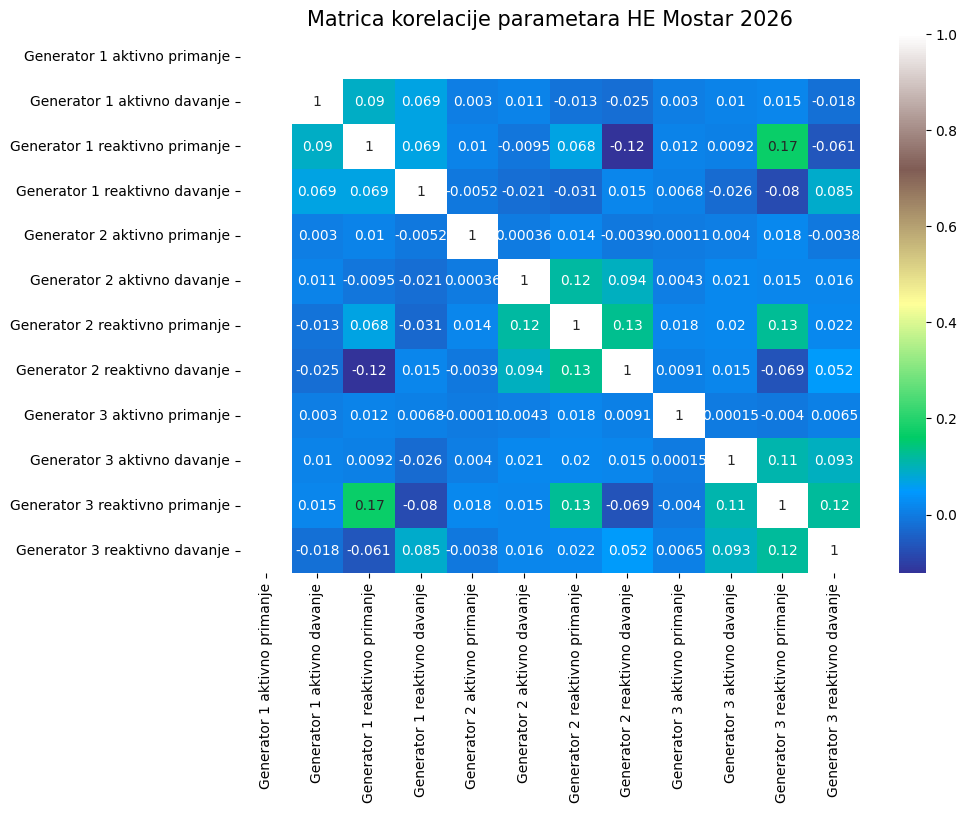

In [ ]:
import seaborn as sns  # Dodajemo ovo da budemo sigurni
import matplotlib.pyplot as plt

# 1. Računanje korelacije (numeric_only=True osigurava da radi samo s brojevima)
matrica_korelacije = df.drop(columns=['Time']).corr()

# 2. Crtanje matrice 
# Sada koristimo 'sns' jer smo ga gore uvezli
sns.heatmap(matrica_korelacije, annot=True, cmap='terrain')

# 3. Podešavanje veličine figure
fig = plt.gcf()
fig.set_size_inches(10, 7)

# 4. Naslov
plt.title('Matrica korelacije parametara HE Mostar 2026', fontsize=15)
plt.show()

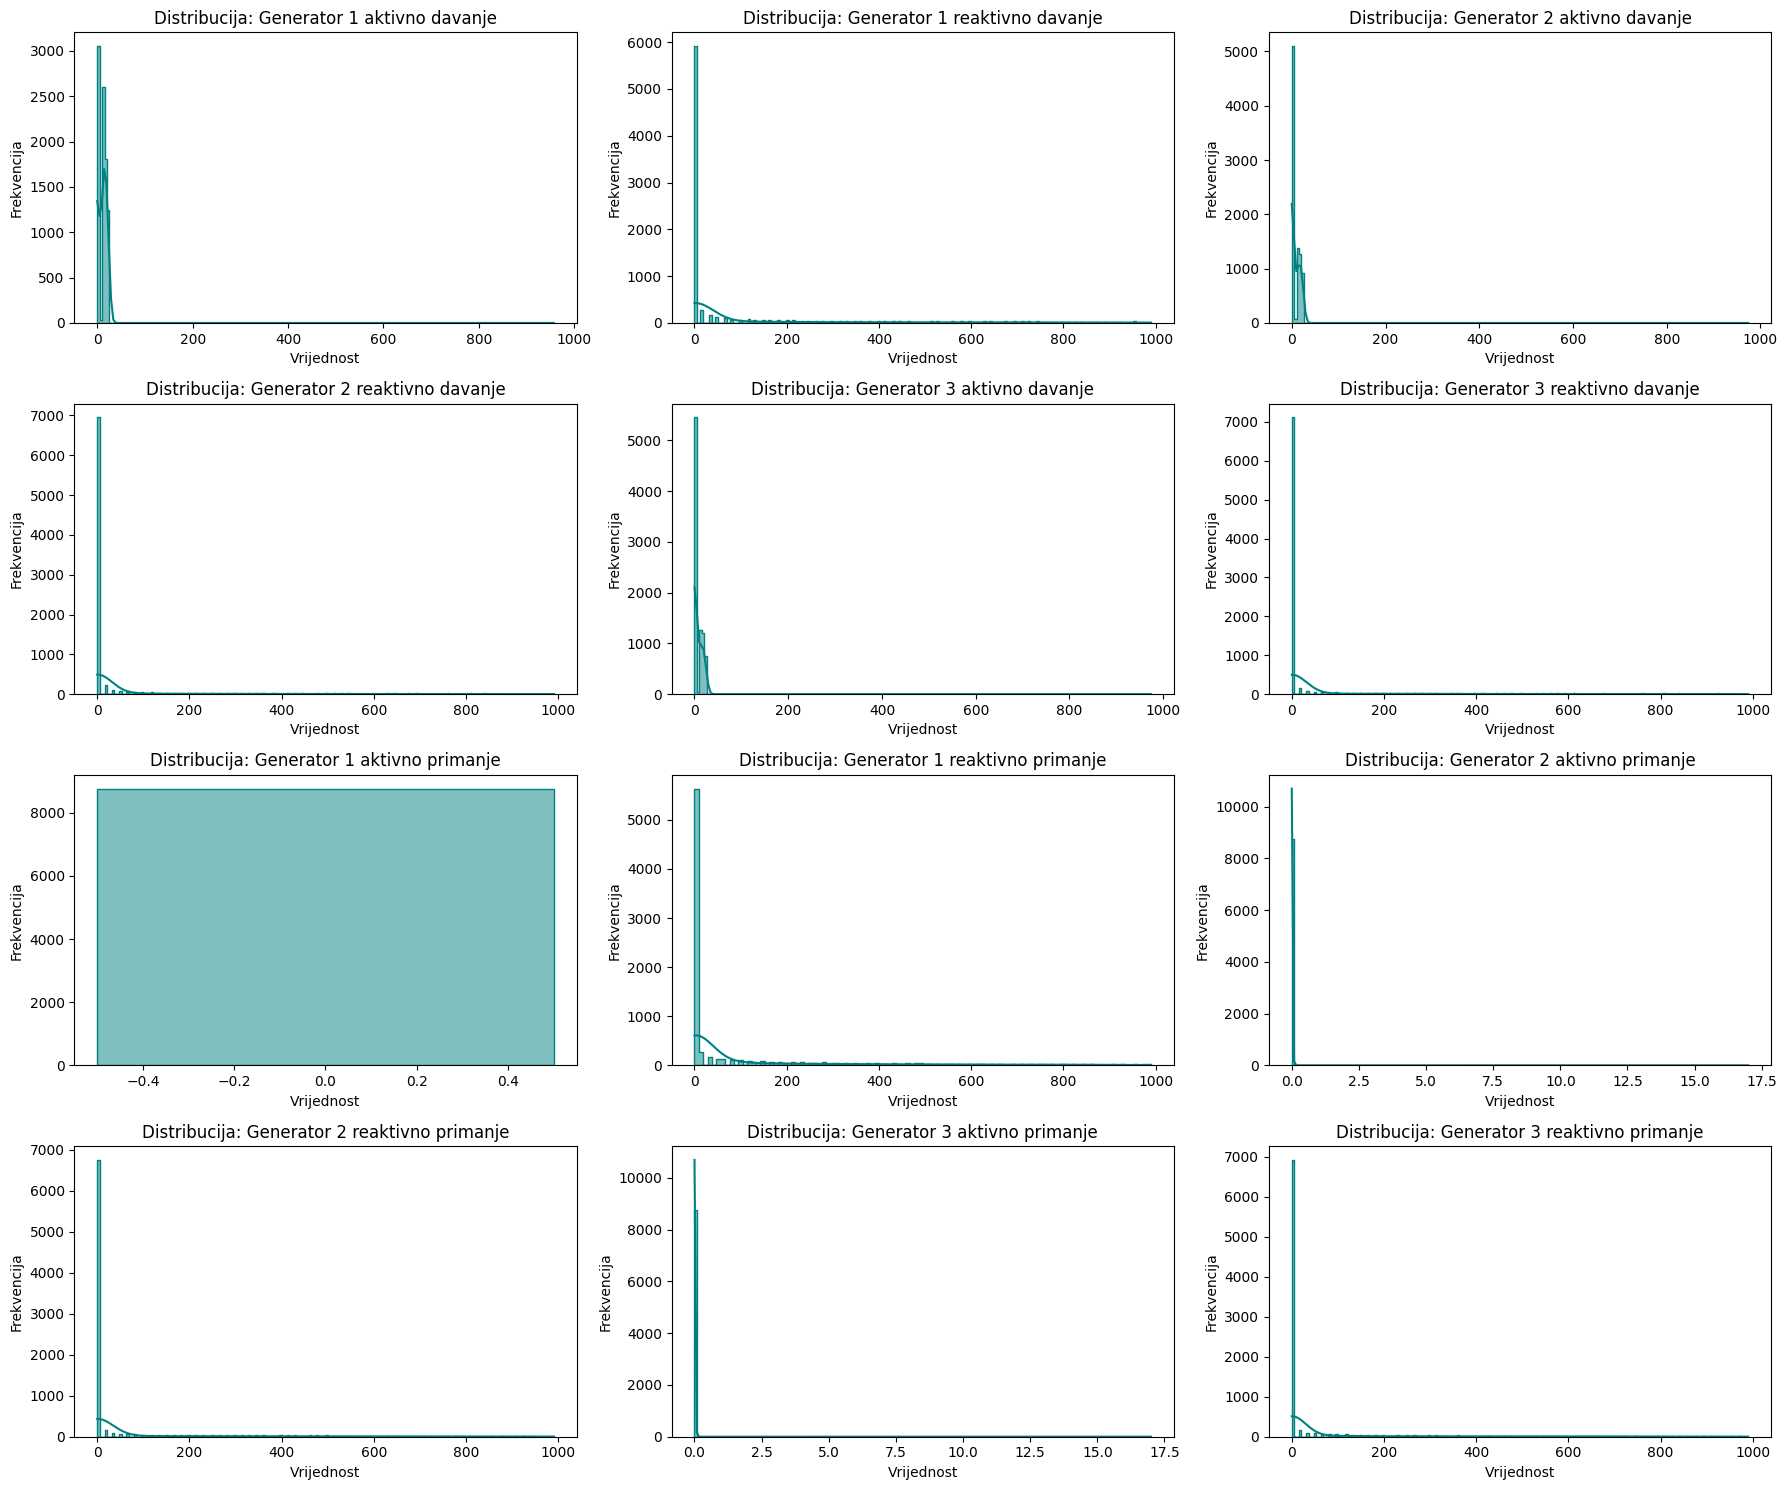

In [ ]:
# Definiramo stupce (atribute) za generatore
# Fokusirat ćemo se na "aktivno davanje" i "reaktivno davanje" jer su najbitniji
features = [
    'Generator 1 aktivno davanje', 'Generator 1 reaktivno davanje',
    'Generator 2 aktivno davanje', 'Generator 2 reaktivno davanje',
    'Generator 3 aktivno davanje', 'Generator 3 reaktivno davanje',
    'Generator 1 aktivno primanje', 'Generator 1 reaktivno primanje',
    'Generator 2 aktivno primanje', 'Generator 2 reaktivno primanje',
    'Generator 3 aktivno primanje', 'Generator 3 reaktivno primanje'
]

plt.figure(figsize=(18, 15))

for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1) # 4 reda i 3 stupca jer imamo 12 grafova
    # Crtamo histogram sa KDE linijom (linija koja pokazuje trend/gustoću)
    sns.histplot(data=df, x=feature, kde=True, color='teal', element='step')
    plt.title(f'Distribucija: {feature}')
    plt.xlabel('Vrijednost')
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

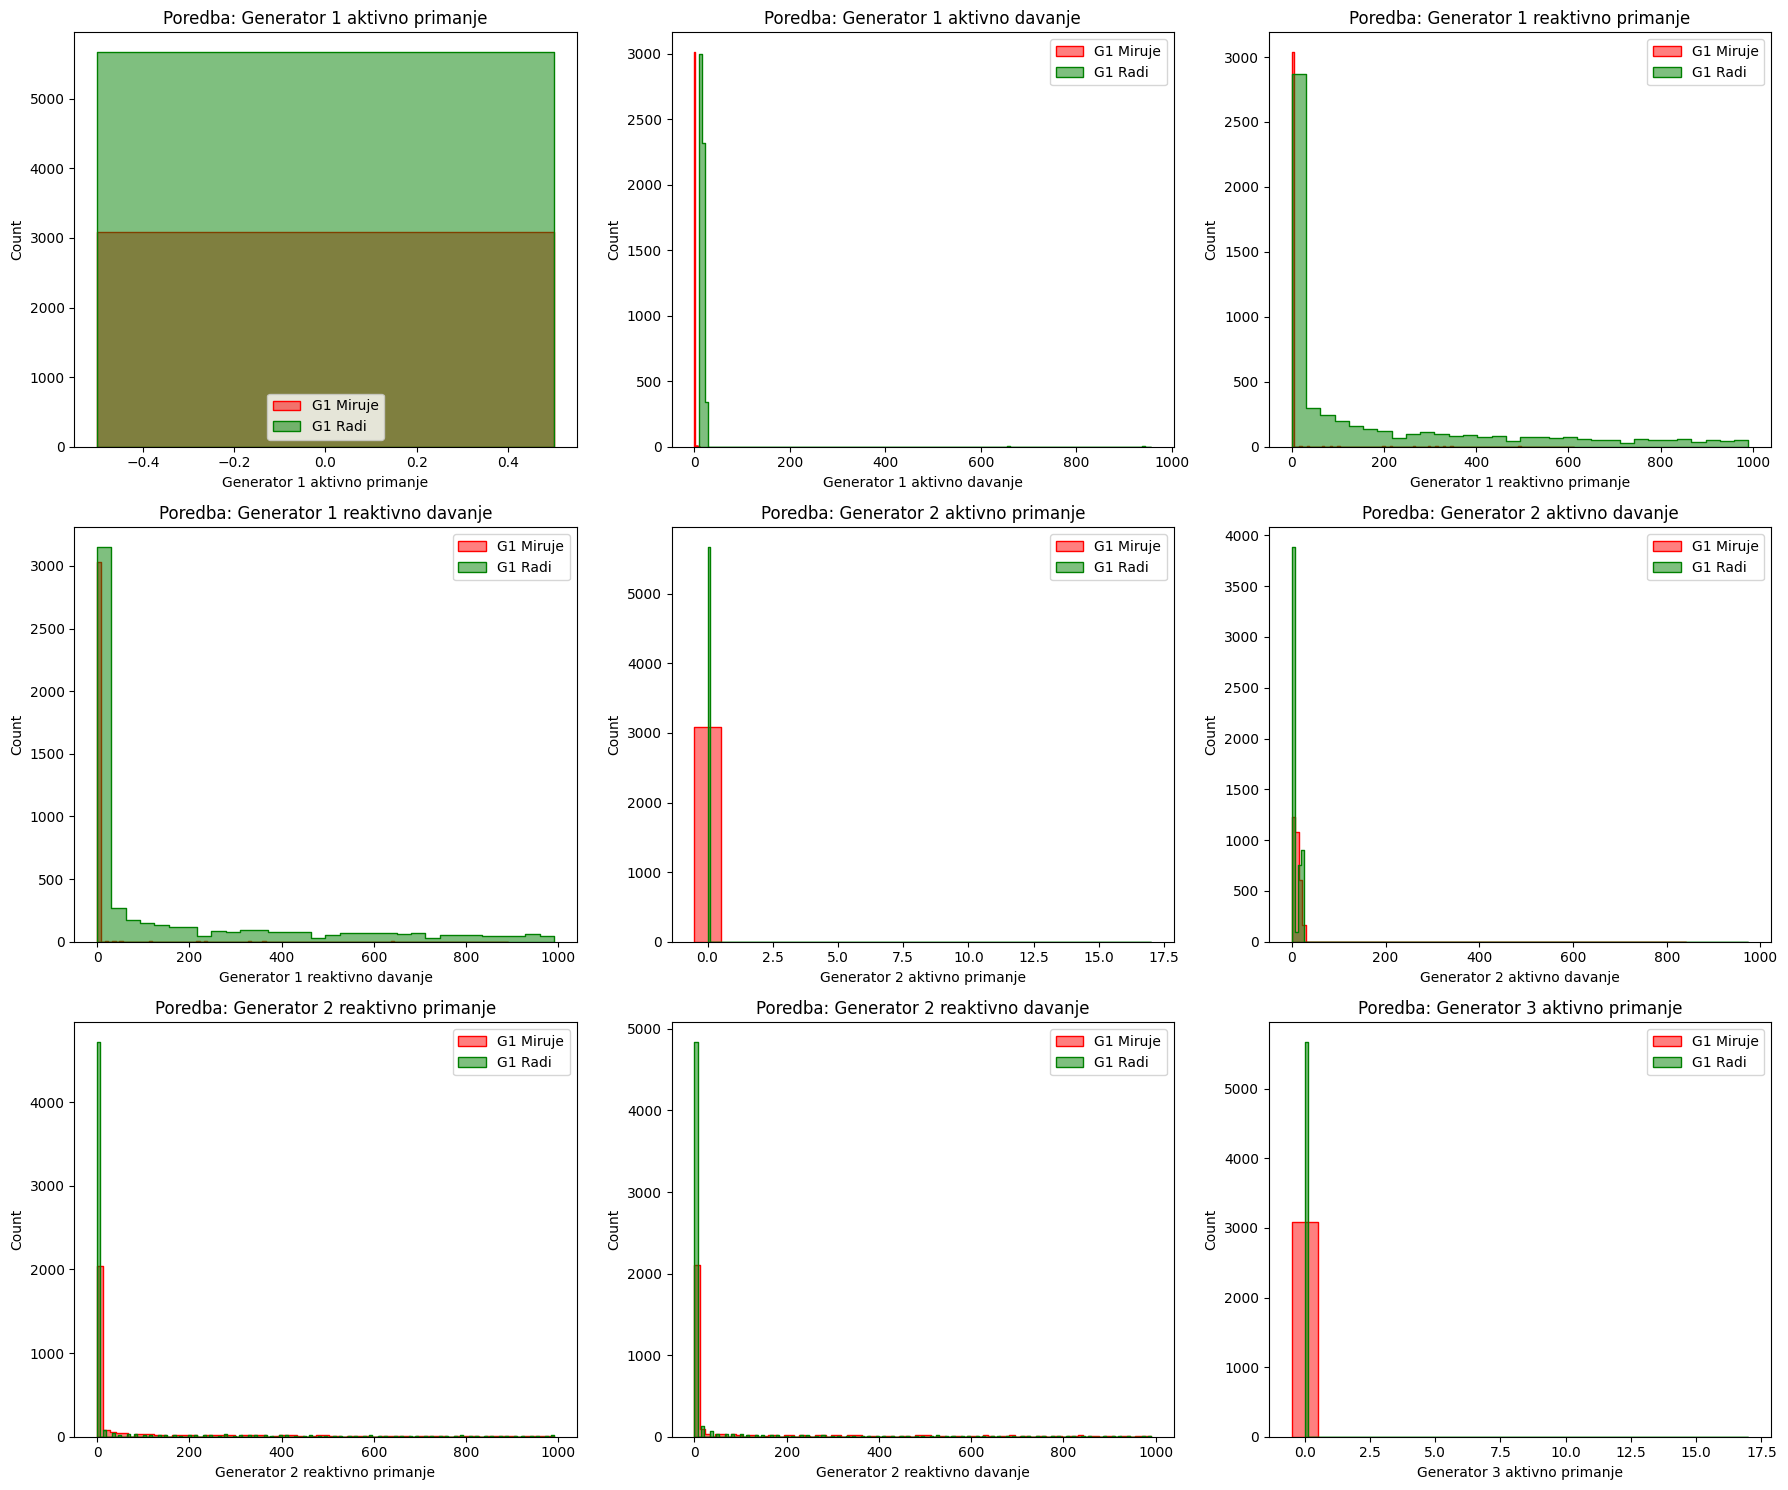

In [13]:
# 1. Definiramo Status (isto kao maloprije)
df['Status_G1'] = (df['Generator 1 aktivno davanje'] > 10).astype(int)

radi = df.query("Status_G1 == 1")
miruje = df.query("Status_G1 == 0")

plt.figure(figsize = (18,15))
# Biramo stupce koji imaju bar malo promjena (da izbjegnemo nule)
stupci_za_poredbu = [col for col in df.columns if col not in ['Time', 'Status_G1']][:9]

for i, col in enumerate(stupci_za_poredbu):
    plt.subplot(3,3,i+1)
    plt.title(f"Poredba: {col}")
    
    # Koristimo histplot koji je otporan na "nula varijancu"
    sns.histplot(x=miruje[col], label="G1 Miruje", color="red", kde=False, element="step", alpha=0.5)
    sns.histplot(x=radi[col], label="G1 Radi", color="green", kde=False, element="step", alpha=0.5)
    
    plt.legend()

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definiramo X (ulazi) i y (izlaz/cilj)
# Izbacujemo 'Time' (jer nije broj), 'Status_G1' (jer je to cilj) 
# i 'Generator 1 aktivno davanje' (jer bi AI odmah znao odgovor po tome)
X = df.drop(columns=['Time', 'Status_G1', 'Generator 1 aktivno davanje'])
y = df['Status_G1']

# 2. Dijelimo podatke: 80% za učenje, 20% za testiranje (provjeru znanja)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Skaliranje (Stavljanje svih brojeva u isti rang, npr. od -1 do 1)
# To pomaže AI-u da brže i bolje uči
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Podaci su spremni! AI ima 7008 sati za učenje, a na 1752 sata ćemo ga testirati.")

Podaci su spremni! AI ima 7008 sati za učenje, a na 1752 sata ćemo ga testirati.


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Stvaramo model (šumu od 100 stabala)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Učenje (Fit) - ovdje AI traži uzorke u radu HE Mostar
model.fit(X_train_scaled, y_train)

# 3. Predviđanje - dajemo mu testne podatke da vidimo koliko je naučio
y_pred = model.predict(X_test_scaled)

# 4. Rezultat
print(f"Preciznost modela (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetaljan izvještaj:")
print(classification_report(y_test, y_pred))

Preciznost modela (Accuracy): 98.69%

Detaljan izvještaj:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       618
           1       0.98      1.00      0.99      1134

    accuracy                           0.99      1752
   macro avg       0.99      0.98      0.99      1752
weighted avg       0.99      0.99      0.99      1752



Točnost modela (Accuracy): 0.9869
------------------------------
KLASIFIKACIJSKI IZVJEŠTAJ:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       618
           1       0.98      1.00      0.99      1134

    accuracy                           0.99      1752
   macro avg       0.99      0.98      0.99      1752
weighted avg       0.99      0.99      0.99      1752



<Figure size 800x600 with 0 Axes>

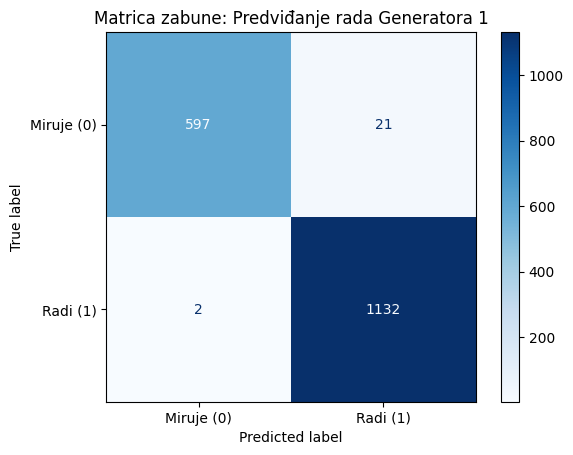

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Izračun predviđanja (već smo napravili, ali ponovimo za svaki slučaj)
y_pred = model.predict(X_test_scaled)

# 2. Ispis točnosti
tocnost = accuracy_score(y_test, y_pred)
print(f"Točnost modela (Accuracy): {tocnost:.4f}")
print("-" * 30)

# 3. Detaljan izvještaj (Precision, Recall, F1-score)
print("KLASIFIKACIJSKI IZVJEŠTAJ:")
print(classification_report(y_test, y_pred))

# 4. GRAFIČKI PRIKAZ: Matrica zabune (Confusion Matrix)
# Ovo je onaj grafikon koji pokazuje gdje je AI pogriješio
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matrica zabune: Predviđanje rada Generatora 1')
plt.show()

Točnost Logističke regresije: 0.8076


<Figure size 800x600 with 0 Axes>

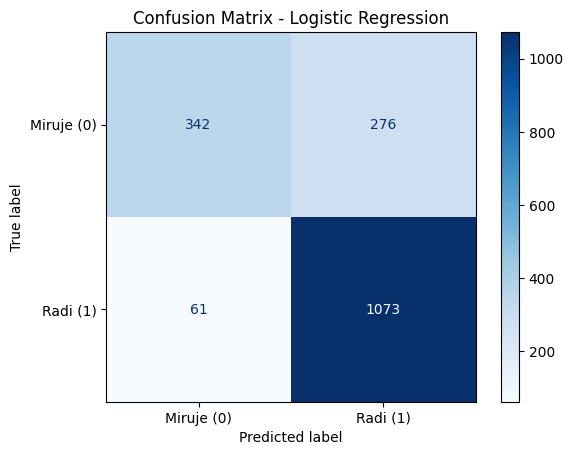

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Stvaranje modela
# Koristimo random_state=42 da rezultati uvijek budu isti
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# 2. Učenje modela (Fit)
model_lr.fit(X_train_scaled, y_train)

# 3. Predviđanje na testnom skupu
y_pred_lr = model_lr.predict(X_test_scaled)

# 4. Prikaz točnosti
print(f"Točnost Logističke regresije: {accuracy_score(y_test, y_pred_lr):.4f}")

# 5. Prikaz Matrice konfuzije
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Točnost SVM modela: 0.8505


<Figure size 800x600 with 0 Axes>

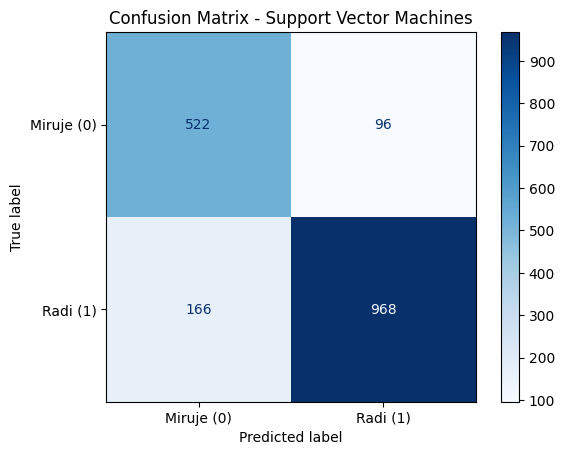

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Stvaranje modela (SVC - Support Vector Classifier)
# random_state=42 
model_svm = SVC(random_state=42)

# 2. Učenje modela
# Ovdje AI pokušava pronaći tu "savršenu granicu" u tvom oblaku podataka
model_svm.fit(X_train_scaled, y_train)

# 3. Predviđanje na testnim podacima
y_pred_svm = model_svm.predict(X_test_scaled)

# 4. Ispis točnosti
print(f"Točnost SVM modela: {accuracy_score(y_test, y_pred_svm):.4f}")

# 5. Prikaz Matrice konfuzije
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Support Vector Machines')
plt.show()

Točnost KNN modela: 0.9269


<Figure size 800x600 with 0 Axes>

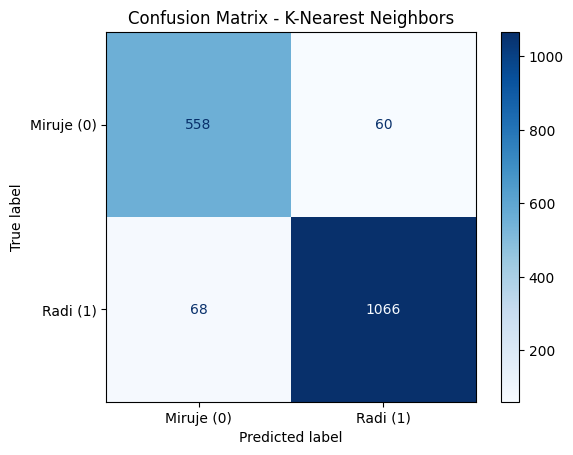

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Stvaranje modela
# Po defaultu koristi 5 susjeda (n_neighbors=5)
model_knn = KNeighborsClassifier()

# 2. Učenje modela
# KNN zapravo samo "pamti" tvoje skalirane podatke
model_knn.fit(X_train_scaled, y_train)

# 3. Predviđanje
y_pred_knn = model_knn.predict(X_test_scaled)

# 4. Ispis točnosti
print(f"Točnost KNN modela: {accuracy_score(y_test, y_pred_knn):.4f}")

# 5. Prikaz Matrice konfuzije
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.show()

Točnost Decision Tree modela: 0.9823


<Figure size 800x600 with 0 Axes>

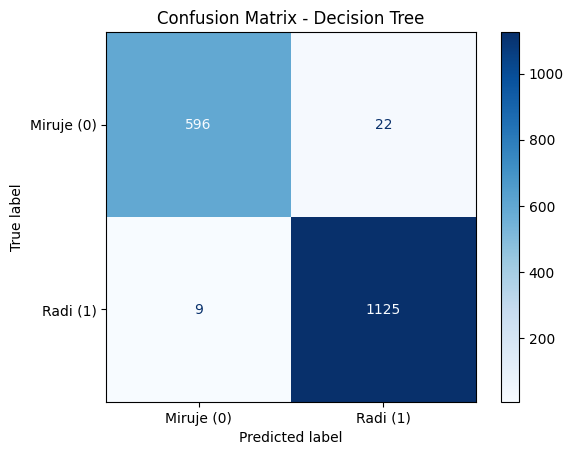

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Stvaranje modela stabla odlučivanja
# Postavljamo random_state=42 kako bi rezultati bili ponovljivi
model_dt = DecisionTreeClassifier(random_state=42)

# 2. Učenje modela (Fit)
# Ovdje stablo "raste" i uči pravila na temelju podataka iz Mostara
model_dt.fit(X_train_scaled, y_train)

# 3. Predviđanje na testnom skupu
y_pred_dt = model_dt.predict(X_test_scaled)

# 4. Ispis rezultata točnosti
print(f"Točnost Decision Tree modela: {accuracy_score(y_test, y_pred_dt):.4f}")

# 5. Prikaz Matrice konfuzije
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Točnost Random Forest modela (100 stabala): 0.9869


<Figure size 800x600 with 0 Axes>

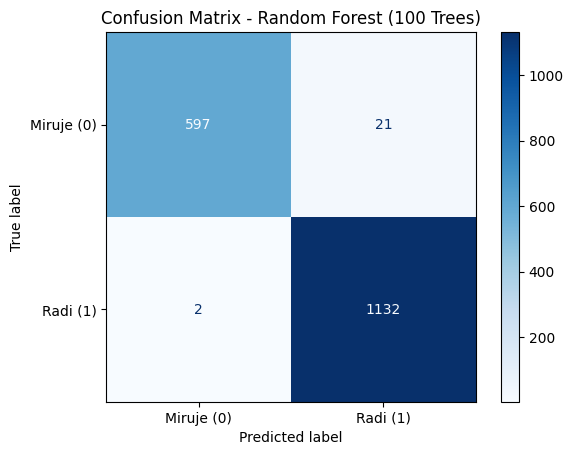

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Inicijalizacija šume sa 100 stabala
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Treniranje modela na tvojim skaliranim podacima
model_rf.fit(X_train_scaled, y_train)

# 3. Predviđanje
y_pred_rf = model_rf.predict(X_test_scaled)

# 4. Ispis točnosti - usporedi ovo s onih 0.6783 
print(f"Točnost Random Forest modela (100 stabala): {accuracy_score(y_test, y_pred_rf):.4f}")

# 5. Prikaz Matrice konfuzije
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miruje (0)', 'Radi (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest (100 Trees)')
plt.show()

--- USPOREDBA MODELA (CROSS-VALIDATION) ---
LogisticRegression        | Prosječna točnost: 0.8008
RandomForestClassifier    | Prosječna točnost: 0.9917
SVC                       | Prosječna točnost: 0.8440
KNeighborsClassifier      | Prosječna točnost: 0.9158
DecisionTreeClassifier    | Prosječna točnost: 0.9863


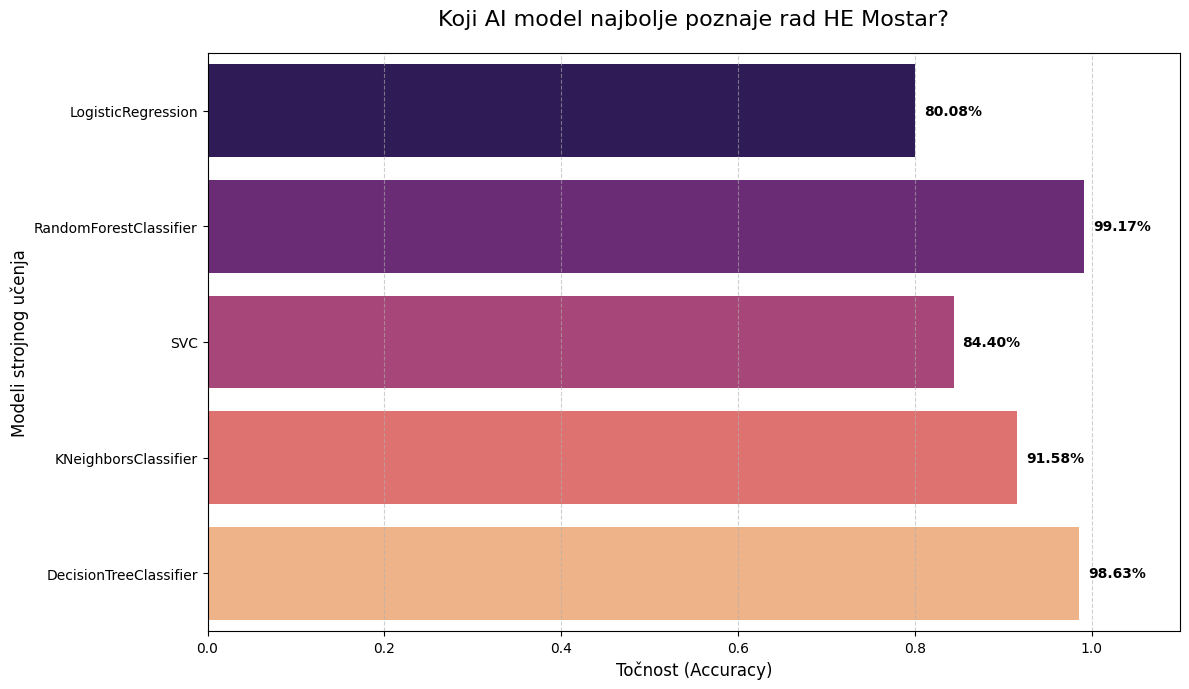

In [23]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definiranje modela za usporedbu
models = [
    LogisticRegression(random_state=42, max_iter=1000),
    RandomForestClassifier(random_state=42, n_estimators=100),
    SVC(random_state=42),
    KNeighborsClassifier(),
    DecisionTreeClassifier(random_state=42)
]

imena_modela = []
prosjecne_tocnosti = []

# 2. Izvođenje unakrsne provjere (Cross-Validation)
print("--- USPOREDBA MODELA (CROSS-VALIDATION) ---")
for model in models:
    ime = model.__class__.__name__
    # cv=5 znači da model testiramo na 5 različitih dijelova podataka
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    srednja_vrijednost = np.mean(scores)
    
    imena_modela.append(ime)
    prosjecne_tocnosti.append(srednja_vrijednost)
    
    print(f'{ime:25} | Prosječna točnost: {srednja_vrijednost:.4f}')

# 3. Vizualni prikaz rezultata (Sada bez upozorenja)
plt.figure(figsize=(12, 7))

# Dodajemo hue=imena_modela i legend=False da eliminiramo FutureWarning
sns.barplot(x=prosjecne_tocnosti, y=imena_modela, hue=imena_modela, palette='magma', legend=False)

# Dodatna estetika grafikona
plt.xlim(0, 1.1)  # Skala ide malo preko 1.0 radi preglednosti
plt.title('Koji AI model najbolje poznaje rad HE Mostar?', fontsize=16, pad=20)
plt.xlabel('Točnost (Accuracy)', fontsize=12)
plt.ylabel('Modeli strojnog učenja', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Ispisivanje točnog postotka na kraju svakog stupca
for i, v in enumerate(prosjecne_tocnosti):
    plt.text(v + 0.01, i, f'{v*100:.2f}%', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

--- DETALJNI IZVJEŠTAJ PERFORMANSI (RANDOM FOREST) ---
              precision    recall  f1-score   support

  Miruje (0)       1.00      0.97      0.98       618
    Radi (1)       0.98      1.00      0.99      1134

    accuracy                           0.99      1752
   macro avg       0.99      0.98      0.99      1752
weighted avg       0.99      0.99      0.99      1752



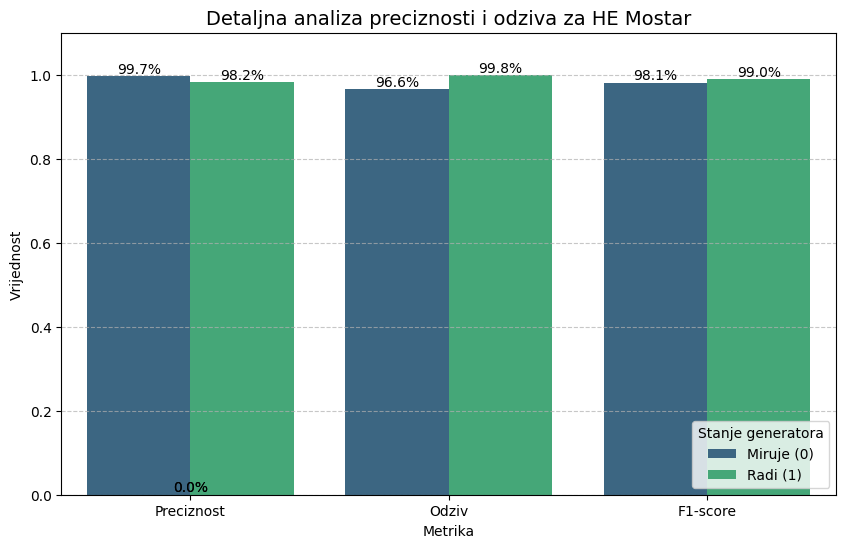

In [25]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

# 1. Generiranje predviđanja za najbolji model (Random Forest)
y_pred_final = model_rf.predict(X_test_scaled)

# 2. Dobivanje tekstualnog izvještaja
report = classification_report(y_test, y_pred_final, target_names=['Miruje (0)', 'Radi (1)'])
print("--- DETALJNI IZVJEŠTAJ PERFORMANSI (RANDOM FOREST) ---")
print(report)

# 3. Vizualizacija ovih mjera radi lakšeg razumijevanja
metrics = precision_recall_fscore_support(y_test, y_pred_final, average=None, labels=[0, 1])
metrics_df = pd.DataFrame({
    'Metrika': ['Preciznost', 'Odziv', 'F1-score'],
    'Miruje (0)': [metrics[0][0], metrics[1][0], metrics[2][0]],
    'Radi (1)': [metrics[0][1], metrics[1][1], metrics[2][1]]
})

# Pretvaranje u "long format" za lakše crtanje
metrics_melted = metrics_df.melt(id_vars='Metrika', var_name='Stanje', value_name='Vrijednost')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Metrika', y='Vrijednost', hue='Stanje', palette='viridis')
plt.ylim(0, 1.1)
plt.title('Detaljna analiza preciznosti i odziva za HE Mostar', fontsize=14)
plt.legend(title='Stanje generatora', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodavanje postotaka na stupce
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()*100:.1f}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()